
# 09 — Criteo Uplift Modeling and Targeting

**Product Pulse**

Notebook 08 answered:

- **Retailrocket:** who is likely to transact soon?
- **Online Retail II:** who is likely to purchase again?

Notebook 09 answers a different question:

> **Who is more likely to convert because of the treatment?**

This is an **uplift / heterogeneous treatment-effect** problem.

A high-conversion customer is not automatically a good targeting candidate. Some customers may convert whether we treat them or not. Uplift modeling instead estimates:

```text
uplift(x) = P(conversion | treatment, x)
            - P(conversion | control, x)
```

Users with the highest estimated uplift are the users for whom the intervention is expected to make the largest difference.

---

## Dataset

Criteo Uplift contains:

- `f0` … `f11`: pre-treatment user/context features
- `treatment`: randomized treatment assignment
- `exposure`: whether treatment was actually exposed
- `visit`: downstream behavior
- `conversion`: final conversion outcome

### Important causal rule

Only **pre-treatment** features `f0` … `f11` are used as model inputs.

`exposure`, `visit`, and `conversion` occur after treatment assignment, so they are **not** used as predictive features.

---

## Modeling approach

We compare two **T-learners**:

1. Logistic Regression T-learner
2. HistGradientBoosting T-learner

Each T-learner fits two outcome models:

```text
treatment model:  P(Y=1 | X, treatment=1)
control model:    P(Y=1 | X, treatment=0)
```

Then:

```text
estimated uplift =
treatment-model score - control-model score
```

Model selection uses the **validation Qini coefficient**, not test performance.

The test set is used only once for final evaluation.


In [1]:

from pathlib import Path
import gc
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"

CRITEO_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "02_cleaned"
    / "criteo_uplift"
)

ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "09_criteo_uplift_modeling"
)

TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FEATURES = [f"f{i}" for i in range(12)]
TREATMENT = "treatment"
OUTCOME = "conversion"
SECONDARY_OUTCOME = "visit"

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Criteo source:", CRITEO_DIR)
print("Results:", RESULTS_DIR)


Criteo source: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned/criteo_uplift
Results: /Users/noopur/Desktop/resume_projects/ProductPulse/results/09_criteo_uplift_modeling


## 1. Load only the columns needed for uplift modeling

In [2]:

criteo_parts = sorted(
    CRITEO_DIR.glob("*.parquet")
)

if not criteo_parts:
    raise FileNotFoundError(
        f"No Criteo parquet parts found in {CRITEO_DIR}. "
        "Run Notebook 02 first."
    )

needed_columns = (
    FEATURES
    + [
        TREATMENT,
        "exposure",
        SECONDARY_OUTCOME,
        OUTCOME,
    ]
)

frames = []

for i, path in enumerate(criteo_parts, start=1):
    part = pd.read_parquet(
        path,
        columns=needed_columns,
    )

    for col in FEATURES:
        part[col] = pd.to_numeric(
            part[col],
            errors="coerce",
            downcast="float",
        )

    for col in [
        TREATMENT,
        "exposure",
        SECONDARY_OUTCOME,
        OUTCOME,
    ]:
        part[col] = (
            pd.to_numeric(
                part[col],
                errors="coerce",
            )
            .fillna(0)
            .astype("int8")
        )

    frames.append(part)

    print(
        f"Loaded {i}/{len(criteo_parts)}:",
        path.name,
        f"rows={len(part):,}",
    )

criteo = pd.concat(
    frames,
    ignore_index=True,
)

del frames
gc.collect()

criteo["row_id"] = np.arange(
    len(criteo),
    dtype=np.int64,
)

print()
print("Shape:", criteo.shape)
print("Memory MB:", round(
    criteo.memory_usage(deep=True).sum()
    / 1024**2,
    1,
))


Loaded 1/28: part_0000.parquet rows=492,918
Loaded 2/28: part_0001.parquet rows=492,910
Loaded 3/28: part_0002.parquet rows=492,951
Loaded 4/28: part_0003.parquet rows=492,839
Loaded 5/28: part_0004.parquet rows=492,791
Loaded 6/28: part_0005.parquet rows=492,984
Loaded 7/28: part_0006.parquet rows=492,816
Loaded 8/28: part_0007.parquet rows=492,840
Loaded 9/28: part_0008.parquet rows=492,908
Loaded 10/28: part_0009.parquet rows=492,973
Loaded 11/28: part_0010.parquet rows=493,043
Loaded 12/28: part_0011.parquet rows=494,503
Loaded 13/28: part_0012.parquet rows=492,983
Loaded 14/28: part_0013.parquet rows=499,022
Loaded 15/28: part_0014.parquet rows=498,221
Loaded 16/28: part_0015.parquet rows=498,256
Loaded 17/28: part_0016.parquet rows=499,116
Loaded 18/28: part_0017.parquet rows=498,580
Loaded 19/28: part_0018.parquet rows=498,454
Loaded 20/28: part_0019.parquet rows=498,456
Loaded 21/28: part_0020.parquet rows=499,092
Loaded 22/28: part_0021.parquet rows=498,275
Loaded 23/28: part_

In [3]:

dataset_summary = pd.DataFrame([{
    "rows": len(criteo),
    "features": len(FEATURES),
    "treated_rows": int(
        (criteo[TREATMENT] == 1).sum()
    ),
    "control_rows": int(
        (criteo[TREATMENT] == 0).sum()
    ),
    "treated_share_pct": 100 * criteo[
        TREATMENT
    ].mean(),
    "conversion_rate_pct": 100 * criteo[
        OUTCOME
    ].mean(),
    "visit_rate_pct": 100 * criteo[
        SECONDARY_OUTCOME
    ].mean(),
}])

display(dataset_summary)


,rows,features,treated_rows,control_rows,treated_share_pct,conversion_rate_pct,visit_rate_pct
0,13851981,12,11770004,2081977,84.969825,0.294355,4.742484



## 2. Observed average treatment effect

Because treatment assignment is randomized, the raw difference between treated and control conversion rates is an unbiased estimate of the **average treatment effect** for the experiment population.

This is the overall effect. Uplift modeling asks whether that effect differs across users.


In [4]:

def observed_effect_table(df, outcome):
    grouped = (
        df.groupby(TREATMENT)[outcome]
        .agg(["count", "mean"])
        .reset_index()
    )

    control_rate = grouped.loc[
        grouped[TREATMENT] == 0,
        "mean",
    ].iloc[0]

    treatment_rate = grouped.loc[
        grouped[TREATMENT] == 1,
        "mean",
    ].iloc[0]

    return grouped, treatment_rate - control_rate


conversion_by_treatment, conversion_ate = (
    observed_effect_table(
        criteo,
        OUTCOME,
    )
)

visit_by_treatment, visit_ate = (
    observed_effect_table(
        criteo,
        SECONDARY_OUTCOME,
    )
)

print("Conversion:")
display(conversion_by_treatment)

print(
    "Observed conversion ATE:",
    f"{conversion_ate:.6f}",
    f"({100 * conversion_ate:.4f} percentage points)",
)

print("\nVisit:")
display(visit_by_treatment)

print(
    "Observed visit ATE:",
    f"{visit_ate:.6f}",
    f"({100 * visit_ate:.4f} percentage points)",
)


Conversion:


,treatment,count,mean
0,0,2081977,0.001952
1,1,11770004,0.003119


Observed conversion ATE: 0.001168 (0.1168 percentage points)

Visit:


,treatment,count,mean
0,0,2081977,0.038475
1,1,11770004,0.049008


Observed visit ATE: 0.010532 (1.0532 percentage points)



## 3. Exact stratified train / validation / test split

We split independently inside each:

```text
treatment × conversion
```

stratum.

This preserves the treatment/control and conversion composition across:

- 70% train
- 15% validation
- 15% test

The split is performed **before model training**.


In [5]:

rng = np.random.default_rng(
    RANDOM_STATE
)

split_code = np.empty(
    len(criteo),
    dtype=np.int8,
)

# 0=train, 1=validation, 2=test
for treatment_value in [0, 1]:
    for outcome_value in [0, 1]:
        idx = np.flatnonzero(
            (
                criteo[TREATMENT].to_numpy()
                == treatment_value
            )
            &
            (
                criteo[OUTCOME].to_numpy()
                == outcome_value
            )
        )

        rng.shuffle(idx)

        n = len(idx)
        n_train = int(
            np.floor(0.70 * n)
        )
        n_val = int(
            np.floor(0.15 * n)
        )

        split_code[
            idx[:n_train]
        ] = 0

        split_code[
            idx[
                n_train:
                n_train + n_val
            ]
        ] = 1

        split_code[
            idx[
                n_train + n_val:
            ]
        ] = 2

        print(
            f"treatment={treatment_value}, "
            f"conversion={outcome_value}: "
            f"{n:,} rows"
        )

criteo["split_code"] = split_code

split_names = {
    0: "train",
    1: "validation",
    2: "test",
}


treatment=0, conversion=0: 2,077,914 rows
treatment=0, conversion=1: 4,063 rows
treatment=1, conversion=0: 11,733,293 rows
treatment=1, conversion=1: 36,711 rows


In [6]:

split_summary_rows = []

for code_value, split_name in split_names.items():
    mask = (
        criteo["split_code"]
        == code_value
    )

    df = criteo.loc[mask]

    treated = df.loc[
        df[TREATMENT] == 1
    ]

    control = df.loc[
        df[TREATMENT] == 0
    ]

    split_summary_rows.append({
        "split": split_name,
        "rows": len(df),
        "treated_share_pct": (
            100
            * df[TREATMENT].mean()
        ),
        "conversion_rate_pct": (
            100
            * df[OUTCOME].mean()
        ),
        "treated_conversion_rate_pct": (
            100
            * treated[OUTCOME].mean()
        ),
        "control_conversion_rate_pct": (
            100
            * control[OUTCOME].mean()
        ),
        "observed_uplift_pp": (
            100
            * (
                treated[OUTCOME].mean()
                - control[OUTCOME].mean()
            )
        ),
    })

split_summary = pd.DataFrame(
    split_summary_rows
)

display(split_summary)


,split,rows,treated_share_pct,conversion_rate_pct,treated_conversion_rate_pct,control_conversion_rate_pct,observed_uplift_pp
0,train,9696385,84.969832,0.294347,0.311895,0.195144,0.116750
1,validation,2077795,84.969836,0.294302,0.311867,0.195007,0.116859
2,test,2077801,84.969783,0.294446,0.311979,0.195326,0.116653



## 4. Treatment-balance check

Randomization should make the treatment and control populations similar on pre-treatment features.

We verify this using **standardized mean differences (SMD)**.

A common diagnostic convention is:

```text
|SMD| < 0.10
```

for reasonably balanced covariates.


In [7]:

def standardized_mean_difference(
    treated_values,
    control_values,
):
    treated_values = pd.Series(
        treated_values
    ).dropna()

    control_values = pd.Series(
        control_values
    ).dropna()

    mean_t = treated_values.mean()
    mean_c = control_values.mean()

    var_t = treated_values.var(ddof=1)
    var_c = control_values.var(ddof=1)

    pooled_sd = np.sqrt(
        (var_t + var_c) / 2
    )

    if pooled_sd == 0:
        return 0.0

    return float(
        (mean_t - mean_c)
        / pooled_sd
    )


balance_rows = []

for feature in FEATURES:
    smd = standardized_mean_difference(
        criteo.loc[
            criteo[TREATMENT] == 1,
            feature,
        ],
        criteo.loc[
            criteo[TREATMENT] == 0,
            feature,
        ],
    )

    balance_rows.append({
        "feature": feature,
        "smd": smd,
        "abs_smd": abs(smd),
    })

feature_balance = (
    pd.DataFrame(balance_rows)
    .sort_values(
        "abs_smd",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_balance)

print(
    "Maximum absolute SMD:",
    round(
        feature_balance[
            "abs_smd"
        ].max(),
        6,
    ),
)


,feature,smd,abs_smd
0,f3,-0.049820,0.049820
1,f6,-0.042138,0.042138
2,f5,-0.031150,0.031150
3,f9,0.024965,0.024965
4,f1,0.024378,0.024378
5,f8,-0.023863,0.023863
6,f7,0.021869,0.021869
7,f10,0.009123,0.009123
8,f4,0.007646,0.007646
9,f0,-0.007076,0.007076


Maximum absolute SMD: 0.04982



## 5. Uplift evaluation functions

We evaluate ranking quality rather than ordinary classification accuracy.

### Qini curve

After ranking users from highest to lowest estimated uplift, the cumulative gain compares:

- observed treated conversions
- versus the number expected from the corresponding control population.

A stronger uplift model pushes incremental conversions toward the top of the ranking.

### Targeting tables

We also report observed treatment lift among the:

- top 1%
- top 5%
- top 10%
- top 20%
- full population


In [8]:

def qini_curve(
    y,
    treatment,
    uplift_score,
    n_points=200,
):
    y = np.asarray(y).astype(float)
    treatment = np.asarray(
        treatment
    ).astype(int)
    uplift_score = np.asarray(
        uplift_score
    ).astype(float)

    order = np.argsort(
        uplift_score
    )[::-1]

    y = y[order]
    treatment = treatment[order]

    treated = (
        treatment == 1
    ).astype(float)

    control = (
        treatment == 0
    ).astype(float)

    cum_treated_n = np.cumsum(
        treated
    )

    cum_control_n = np.cumsum(
        control
    )

    cum_treated_y = np.cumsum(
        y * treated
    )

    cum_control_y = np.cumsum(
        y * control
    )

    expected_control_conversions = (
        np.divide(
            cum_control_y
            * cum_treated_n,
            cum_control_n,
            out=np.zeros_like(
                cum_control_y,
                dtype=float,
            ),
            where=(
                cum_control_n > 0
            ),
        )
    )

    gain = (
        cum_treated_y
        - expected_control_conversions
    )

    n = len(y)

    positions = np.unique(
        np.linspace(
            1,
            n,
            min(n_points, n),
            dtype=int,
        )
    )

    idx = positions - 1
    fraction = positions / n

    sampled_gain = gain[idx]

    return pd.DataFrame({
        "fraction_targeted": fraction,
        "qini_gain": sampled_gain,
    })


def qini_coefficient(
    y,
    treatment,
    uplift_score,
):
    curve = qini_curve(
        y,
        treatment,
        uplift_score,
        n_points=500,
    )

    x = curve[
        "fraction_targeted"
    ].to_numpy()

    gain = curve[
        "qini_gain"
    ].to_numpy()

    if len(x) < 2:
        return np.nan

    random_gain = (
        x * gain[-1]
    )

    qini = np.trapz(
        gain - random_gain,
        x,
    )

    return float(qini)


def targeting_table(
    y,
    treatment,
    uplift_score,
    fractions=(
        0.01,
        0.05,
        0.10,
        0.20,
        1.00,
    ),
):
    y = np.asarray(y)
    treatment = np.asarray(
        treatment
    )
    uplift_score = np.asarray(
        uplift_score
    )

    order = np.argsort(
        uplift_score
    )[::-1]

    rows = []

    for fraction in fractions:
        n = max(
            1,
            int(
                np.ceil(
                    len(y)
                    * fraction
                )
            ),
        )

        idx = order[:n]

        y_top = y[idx]
        t_top = treatment[idx]

        treated_mask = (
            t_top == 1
        )
        control_mask = (
            t_top == 0
        )

        treated_rate = (
            y_top[
                treated_mask
            ].mean()
            if treated_mask.any()
            else np.nan
        )

        control_rate = (
            y_top[
                control_mask
            ].mean()
            if control_mask.any()
            else np.nan
        )

        observed_uplift = (
            treated_rate
            - control_rate
        )

        rows.append({
            "target_fraction": fraction,
            "target_pct": 100 * fraction,
            "rows": n,
            "treated_rows": int(
                treated_mask.sum()
            ),
            "control_rows": int(
                control_mask.sum()
            ),
            "treated_conversion_rate": (
                treated_rate
            ),
            "control_conversion_rate": (
                control_rate
            ),
            "observed_uplift": (
                observed_uplift
            ),
            "observed_uplift_pp": (
                100
                * observed_uplift
            ),
        })

    return pd.DataFrame(rows)



## 6. T-learner model definitions

Logistic Regression is standardized.

HistGradientBoosting does not require feature scaling.

We do **not** apply class balancing here because a T-learner subtracts the treatment and control outcome-model predictions. Artificially reweighting the classes separately in each arm can distort the scale of those two predictions and therefore distort the uplift difference.


In [9]:

def make_logistic_model():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def make_histgb_model():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=150,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def fit_t_learner(
    model_factory,
    X,
    y,
    treatment,
):
    treatment = np.asarray(
        treatment
    )
    y = np.asarray(y)

    treated_mask = (
        treatment == 1
    )
    control_mask = (
        treatment == 0
    )

    treatment_model = (
        model_factory()
    )

    control_model = (
        model_factory()
    )

    treatment_model.fit(
        X.loc[
            treated_mask
        ],
        y[
            treated_mask
        ],
    )

    control_model.fit(
        X.loc[
            control_mask
        ],
        y[
            control_mask
        ],
    )

    return (
        treatment_model,
        control_model,
    )


def predict_uplift(
    treatment_model,
    control_model,
    X,
):
    mu1 = (
        treatment_model
        .predict_proba(X)[:, 1]
    )

    mu0 = (
        control_model
        .predict_proba(X)[:, 1]
    )

    uplift = (
        mu1 - mu0
    )

    return mu1, mu0, uplift



## 7. Prepare train, validation, and test views

To keep memory usage under control, we keep one main Criteo DataFrame and use split masks rather than creating three full copies.


In [10]:

train_mask = (
    criteo["split_code"] == 0
)

val_mask = (
    criteo["split_code"] == 1
)

test_mask = (
    criteo["split_code"] == 2
)

X_train = criteo.loc[
    train_mask,
    FEATURES,
]

y_train = criteo.loc[
    train_mask,
    OUTCOME,
].to_numpy()

t_train = criteo.loc[
    train_mask,
    TREATMENT,
].to_numpy()

X_val = criteo.loc[
    val_mask,
    FEATURES,
]

y_val = criteo.loc[
    val_mask,
    OUTCOME,
].to_numpy()

t_val = criteo.loc[
    val_mask,
    TREATMENT,
].to_numpy()

X_test = criteo.loc[
    test_mask,
    FEATURES,
]

y_test = criteo.loc[
    test_mask,
    OUTCOME,
].to_numpy()

t_test = criteo.loc[
    test_mask,
    TREATMENT,
].to_numpy()

print(
    "Train:",
    f"{len(X_train):,}",
)
print(
    "Validation:",
    f"{len(X_val):,}",
)
print(
    "Test:",
    f"{len(X_test):,}",
)


Train: 9,696,385
Validation: 2,077,795
Test: 2,077,801



## 8. Logistic Regression T-learner

The logistic T-learner is the interpretable baseline.


In [11]:

logit_treatment_model, logit_control_model = (
    fit_t_learner(
        make_logistic_model,
        X_train,
        y_train,
        t_train,
    )
)

print(
    "Logistic T-learner trained."
)


Logistic T-learner trained.


In [12]:

(
    logit_val_mu1,
    logit_val_mu0,
    logit_val_uplift,
) = predict_uplift(
    logit_treatment_model,
    logit_control_model,
    X_val,
)

logit_val_qini = qini_coefficient(
    y_val,
    t_val,
    logit_val_uplift,
)

logit_val_targeting = targeting_table(
    y_val,
    t_val,
    logit_val_uplift,
)

print(
    "Validation Qini:",
    round(
        logit_val_qini,
        6,
    ),
)

display(
    logit_val_targeting
)


Validation Qini: 793.541094


,target_fraction,target_pct,rows,treated_rows,control_rows,treated_conversion_rate,control_conversion_rate,observed_uplift,observed_uplift_pp
0,0.01,1.0,20778,18199,2579,0.135337,0.099263,0.036074,3.607383
1,0.05,5.0,103890,90302,13588,0.044351,0.031130,0.013221,1.322077
2,0.10,10.0,207780,179385,28395,0.025231,0.017080,0.008150,0.815018
3,0.20,20.0,415559,356141,59418,0.013674,0.009004,0.004670,0.467035
4,1.00,100.0,2077795,1765499,312296,0.003119,0.001950,0.001169,0.116859



## 9. HistGradientBoosting T-learner

The treated arm is much larger than the control arm. To keep notebook runtime practical, HGB is trained on a reproducible cap of **2,000,000 rows per arm**.

This is uniform row sampling within each treatment arm, so it does not synthetically alter the feature values or create SMOTE-style observations.

The full validation and test sets remain untouched.


In [13]:

HGB_MAX_ROWS_PER_ARM = 2_000_000


def capped_arm_training_data(
    X,
    y,
    treatment,
    max_rows_per_arm,
    random_state,
):
    rng = np.random.default_rng(
        random_state
    )

    treatment = np.asarray(
        treatment
    )
    y = np.asarray(y)

    selected_positions = []

    for arm in [0, 1]:
        positions = np.flatnonzero(
            treatment == arm
        )

        if (
            max_rows_per_arm is not None
            and len(positions)
            > max_rows_per_arm
        ):
            positions = rng.choice(
                positions,
                size=max_rows_per_arm,
                replace=False,
            )

        selected_positions.append(
            positions
        )

        print(
            f"Arm {arm}: "
            f"{len(positions):,} "
            "training rows"
        )

    selected_positions = np.concatenate(
        selected_positions
    )

    rng.shuffle(
        selected_positions
    )

    return (
        X.iloc[
            selected_positions
        ],
        y[
            selected_positions
        ],
        treatment[
            selected_positions
        ],
    )


(
    X_train_hgb,
    y_train_hgb,
    t_train_hgb,
) = capped_arm_training_data(
    X_train,
    y_train,
    t_train,
    max_rows_per_arm=HGB_MAX_ROWS_PER_ARM,
    random_state=RANDOM_STATE,
)


Arm 0: 1,457,383 training rows
Arm 1: 2,000,000 training rows


In [14]:

hgb_treatment_model, hgb_control_model = (
    fit_t_learner(
        make_histgb_model,
        X_train_hgb,
        y_train_hgb,
        t_train_hgb,
    )
)

print(
    "HistGradientBoosting T-learner trained."
)


HistGradientBoosting T-learner trained.


In [15]:

(
    hgb_val_mu1,
    hgb_val_mu0,
    hgb_val_uplift,
) = predict_uplift(
    hgb_treatment_model,
    hgb_control_model,
    X_val,
)

hgb_val_qini = qini_coefficient(
    y_val,
    t_val,
    hgb_val_uplift,
)

hgb_val_targeting = targeting_table(
    y_val,
    t_val,
    hgb_val_uplift,
)

print(
    "Validation Qini:",
    round(
        hgb_val_qini,
        6,
    ),
)

display(
    hgb_val_targeting
)


Validation Qini: 613.331034


,target_fraction,target_pct,rows,treated_rows,control_rows,treated_conversion_rate,control_conversion_rate,observed_uplift,observed_uplift_pp
0,0.01,1.0,20778,17980,2798,0.126919,0.089350,0.037569,3.756926
1,0.05,5.0,103890,90290,13600,0.039982,0.027868,0.012115,1.211463
2,0.10,10.0,207780,179093,28687,0.022458,0.014850,0.007608,0.760767
3,0.20,20.0,415559,355729,59830,0.012158,0.007655,0.004503,0.450311
4,1.00,100.0,2077795,1765499,312296,0.003119,0.001950,0.001169,0.116859


## 10. Select uplift model using validation Qini

In [16]:

validation_model_metrics = pd.DataFrame([
    {
        "model": "LogisticRegression_TLearner",
        "split": "validation",
        "qini_coefficient": logit_val_qini,
    },
    {
        "model": "HistGradientBoosting_TLearner",
        "split": "validation",
        "qini_coefficient": hgb_val_qini,
    },
]).sort_values(
    "qini_coefficient",
    ascending=False,
)

display(
    validation_model_metrics
)

selected_model_name = (
    validation_model_metrics
    .iloc[0]["model"]
)

print(
    "Selected uplift model:",
    selected_model_name,
)


,model,split,qini_coefficient
0,LogisticRegression_TLearner,validation,793.541094
1,HistGradientBoosting_TLearner,validation,613.331034


Selected uplift model: LogisticRegression_TLearner



## 11. Final untouched test evaluation

The selected model is determined entirely from validation performance.

We now evaluate both models on test for reporting, while the selected model remains fixed.


In [17]:

(
    logit_test_mu1,
    logit_test_mu0,
    logit_test_uplift,
) = predict_uplift(
    logit_treatment_model,
    logit_control_model,
    X_test,
)

(
    hgb_test_mu1,
    hgb_test_mu0,
    hgb_test_uplift,
) = predict_uplift(
    hgb_treatment_model,
    hgb_control_model,
    X_test,
)

logit_test_qini = qini_coefficient(
    y_test,
    t_test,
    logit_test_uplift,
)

hgb_test_qini = qini_coefficient(
    y_test,
    t_test,
    hgb_test_uplift,
)

test_model_metrics = pd.DataFrame([
    {
        "model": "LogisticRegression_TLearner",
        "split": "test",
        "qini_coefficient": logit_test_qini,
    },
    {
        "model": "HistGradientBoosting_TLearner",
        "split": "test",
        "qini_coefficient": hgb_test_qini,
    },
])

display(
    test_model_metrics
)


,model,split,qini_coefficient
0,LogisticRegression_TLearner,test,794.614588
1,HistGradientBoosting_TLearner,test,590.934472


In [18]:

if (
    selected_model_name
    == "HistGradientBoosting_TLearner"
):
    selected_test_mu1 = (
        hgb_test_mu1
    )
    selected_test_mu0 = (
        hgb_test_mu0
    )
    selected_test_uplift = (
        hgb_test_uplift
    )
    selected_treatment_model = (
        hgb_treatment_model
    )
    selected_control_model = (
        hgb_control_model
    )
else:
    selected_test_mu1 = (
        logit_test_mu1
    )
    selected_test_mu0 = (
        logit_test_mu0
    )
    selected_test_uplift = (
        logit_test_uplift
    )
    selected_treatment_model = (
        logit_treatment_model
    )
    selected_control_model = (
        logit_control_model
    )

selected_test_targeting = targeting_table(
    y_test,
    t_test,
    selected_test_uplift,
)

display(
    selected_test_targeting
)


,target_fraction,target_pct,rows,treated_rows,control_rows,treated_conversion_rate,control_conversion_rate,observed_uplift,observed_uplift_pp
0,0.01,1.0,20779,18339,2440,0.138666,0.107787,0.030879,3.087935
1,0.05,5.0,103891,90454,13437,0.044940,0.031108,0.013832,1.383184
2,0.10,10.0,207781,179545,28236,0.025208,0.016858,0.008350,0.835025
3,0.20,20.0,415561,356356,59205,0.013719,0.008901,0.004818,0.481815
4,1.00,100.0,2077801,1765503,312298,0.003120,0.001953,0.001167,0.116653



## 12. Uplift-by-decile analysis

If the model is useful, the highest-scoring deciles should show larger observed treatment lift than lower-scoring deciles.


In [19]:

test_eval = criteo.loc[
    test_mask,
    [
        "row_id",
        TREATMENT,
        OUTCOME,
    ],
].copy()

test_eval[
    "predicted_treatment_conversion"
] = selected_test_mu1

test_eval[
    "predicted_control_conversion"
] = selected_test_mu0

test_eval[
    "uplift_score"
] = selected_test_uplift

test_eval[
    "uplift_decile"
] = pd.qcut(
    test_eval[
        "uplift_score"
    ].rank(
        method="first",
        ascending=False,
    ),
    q=10,
    labels=[
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
    ],
)

decile_rows = []

for decile in range(1, 11):
    group = test_eval.loc[
        test_eval[
            "uplift_decile"
        ] == decile
    ]

    treated = group.loc[
        group[TREATMENT] == 1
    ]

    control = group.loc[
        group[TREATMENT] == 0
    ]

    treated_rate = (
        treated[OUTCOME].mean()
    )

    control_rate = (
        control[OUTCOME].mean()
    )

    decile_rows.append({
        "uplift_decile": decile,
        "rows": len(group),
        "mean_predicted_uplift": (
            group[
                "uplift_score"
            ].mean()
        ),
        "treated_conversion_rate": (
            treated_rate
        ),
        "control_conversion_rate": (
            control_rate
        ),
        "observed_uplift": (
            treated_rate
            - control_rate
        ),
        "observed_uplift_pp": (
            100
            * (
                treated_rate
                - control_rate
            )
        ),
    })

uplift_deciles = pd.DataFrame(
    decile_rows
)

display(
    uplift_deciles
)


,uplift_decile,rows,mean_predicted_uplift,treated_conversion_rate,control_conversion_rate,observed_uplift,observed_uplift_pp
0,1,207781,0.007987,0.025208,0.016858,0.008350,0.835025
1,2,207780,0.000745,0.002053,0.001647,0.000406,0.040623
2,3,207780,0.000397,0.000857,0.000349,0.000508,0.050825
3,4,207780,0.000273,0.000460,0.000660,-0.000199,-0.019919
4,5,207780,0.000201,0.000222,0.000126,0.000096,0.009589
5,6,207780,0.000136,0.000227,0.000095,0.000132,0.013234
6,7,207780,0.000072,0.000159,0.000223,-0.000064,-0.006426
7,8,207780,0.000034,0.000164,0.000127,0.000037,0.003716
8,9,207780,0.000004,0.000119,0.000063,0.000056,0.005618
9,10,207780,-0.000118,0.001306,0.000978,0.000329,0.032873


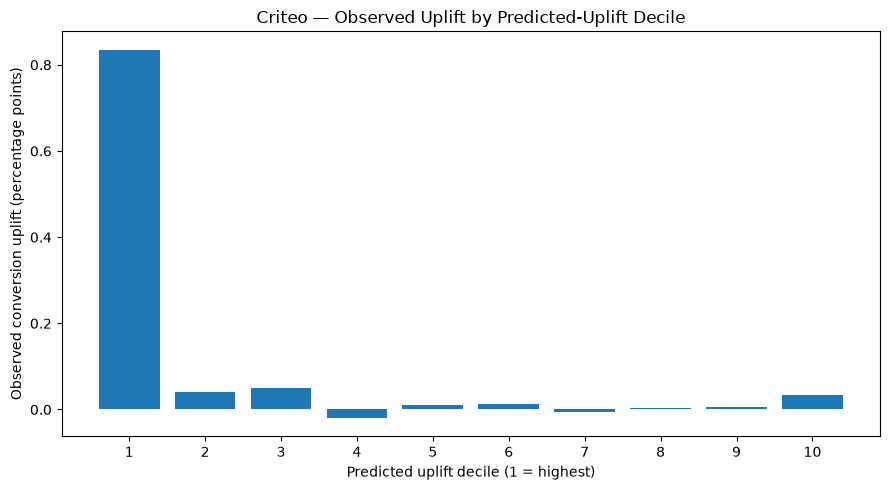

In [20]:

fig_deciles, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    uplift_deciles[
        "uplift_decile"
    ].astype(str),
    uplift_deciles[
        "observed_uplift_pp"
    ],
)

ax.set_xlabel(
    "Predicted uplift decile (1 = highest)"
)

ax.set_ylabel(
    "Observed conversion uplift (percentage points)"
)

ax.set_title(
    "Criteo — Observed Uplift by Predicted-Uplift Decile"
)

fig_deciles.tight_layout()
plt.show()


## 13. Qini curves

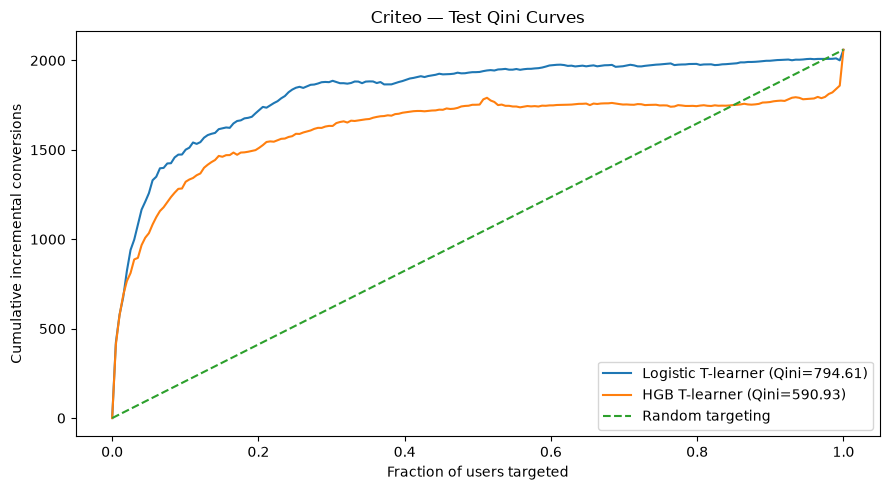

In [21]:

logit_test_qini_curve = qini_curve(
    y_test,
    t_test,
    logit_test_uplift,
    n_points=200,
)

hgb_test_qini_curve = qini_curve(
    y_test,
    t_test,
    hgb_test_uplift,
    n_points=200,
)

fig_qini, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    logit_test_qini_curve[
        "fraction_targeted"
    ],
    logit_test_qini_curve[
        "qini_gain"
    ],
    label=(
        "Logistic T-learner "
        f"(Qini={logit_test_qini:.2f})"
    ),
)

ax.plot(
    hgb_test_qini_curve[
        "fraction_targeted"
    ],
    hgb_test_qini_curve[
        "qini_gain"
    ],
    label=(
        "HGB T-learner "
        f"(Qini={hgb_test_qini:.2f})"
    ),
)

final_gain = (
    logit_test_qini_curve[
        "qini_gain"
    ].iloc[-1]
)

ax.plot(
    [0, 1],
    [0, final_gain],
    linestyle="--",
    label="Random targeting",
)

ax.set_xlabel(
    "Fraction of users targeted"
)

ax.set_ylabel(
    "Cumulative incremental conversions"
)

ax.set_title(
    "Criteo — Test Qini Curves"
)

ax.legend()

fig_qini.tight_layout()
plt.show()



## 14. Highest-uplift users

These are not simply the users with the highest conversion probability.

They are the users for whom the model estimates the **largest treatment-caused improvement**.


In [22]:

top_uplift_users = (
    test_eval
    .sort_values(
        "uplift_score",
        ascending=False,
    )
    .head(100)
    .reset_index(drop=True)
)

display(
    top_uplift_users.head(20)
)


,row_id,treatment,conversion,predicted_treatment_conversion,predicted_control_conversion,uplift_score,uplift_decile
0,2723639,1,0,0.627771,0.392585,0.235186,1
1,5813430,0,0,0.553107,0.320227,0.232880,1
2,13340183,1,1,0.546850,0.324183,0.222667,1
3,198035,1,0,0.585388,0.363512,0.221876,1
4,1506906,1,0,0.428195,0.207735,0.220460,1
5,2191482,1,1,0.458858,0.239616,0.219242,1
6,1005169,1,0,0.550596,0.331412,0.219184,1
7,1019566,1,1,0.537288,0.319429,0.217860,1
8,6102491,0,0,0.735122,0.518550,0.216571,1
9,373228,1,1,0.681007,0.464885,0.216121,1


## 15. Save compact Notebook 09 results and model artifact

In [23]:

model_metrics = pd.concat(
    [
        validation_model_metrics,
        test_model_metrics,
    ],
    ignore_index=True,
)

model_selection = pd.DataFrame([{
    "task": "Criteo conversion uplift",
    "selected_model": selected_model_name,
    "selection_metric": "validation_qini_coefficient",
    "features": ",".join(FEATURES),
    "treatment": TREATMENT,
    "outcome": OUTCOME,
}])

RESULT_TABLES = {
    "dataset_summary": dataset_summary,
    "conversion_by_treatment": conversion_by_treatment,
    "visit_by_treatment": visit_by_treatment,
    "split_summary": split_summary,
    "feature_balance": feature_balance,
    "validation_model_metrics": validation_model_metrics,
    "test_model_metrics": test_model_metrics,
    "model_metrics": model_metrics,
    "model_selection": model_selection,
    "selected_test_targeting": selected_test_targeting,
    "uplift_deciles": uplift_deciles,
    "top_uplift_users": top_uplift_users,
    "logistic_test_qini_curve": logit_test_qini_curve,
    "hgb_test_qini_curve": hgb_test_qini_curve,
}

RESULT_FIGURES = {
    "uplift_by_decile": fig_deciles,
    "test_qini_curves": fig_qini,
}

for name, table in RESULT_TABLES.items():
    table.to_csv(
        TABLES_DIR / f"{name}.csv",
        index=False,
    )

for name, fig in RESULT_FIGURES.items():
    fig.savefig(
        FIGURES_DIR / f"{name}.png",
        dpi=200,
        bbox_inches="tight",
    )

joblib.dump(
    {
        "task": "Criteo conversion uplift",
        "treatment_model": selected_treatment_model,
        "control_model": selected_control_model,
        "features": FEATURES,
        "treatment": TREATMENT,
        "outcome": OUTCOME,
        "model_name": selected_model_name,
        "score_name": "uplift_score",
    },
    ARTIFACTS_DIR
    / "criteo_conversion_uplift_model.joblib",
)

print("=" * 72)
print("NOTEBOOK 09 COMPLETE")
print("=" * 72)

print("\nSelected model:")
print(selected_model_name)

print("\nResults:")
print(RESULTS_DIR)

print("\nModel artifact:")
print(
    ARTIFACTS_DIR
    / "criteo_conversion_uplift_model.joblib"
)


NOTEBOOK 09 COMPLETE

Selected model:
LogisticRegression_TLearner

Results:
/Users/noopur/Desktop/resume_projects/ProductPulse/results/09_criteo_uplift_modeling

Model artifact:
/Users/noopur/Desktop/resume_projects/ProductPulse/artifacts/models/criteo_conversion_uplift_model.joblib
